# Практическая работа №2

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Задание 1. Графическое отделение корней

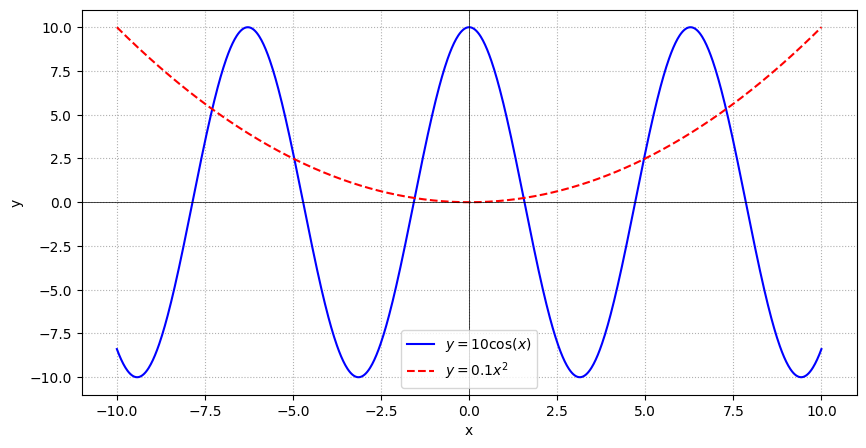

In [2]:
# Определяем функции 10 * cos(x) и 0.1 * x^2
def f1(x):
    return 10 * np.cos(x)

def f2(x):
    return 0.1 * x**2

# Генерируем данные для графика
x = np.linspace(-10, 10, 1000)

plt.figure(figsize=(10, 5))
plt.plot(x, f1(x), label=r'$y = 10\cos(x)$', color='blue')
plt.plot(x, f2(x), label=r'$y = 0.1x^2$', color='red', linestyle='--')

plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True, linestyle=':')
plt.show()

Из графика видно, что уравнение имеет несколько корней.
Возьмем для дальнейшего уточнения положительный корень на отрезке [0, 2.5].

## Задание 2. Метод половинного деления (дихотомии)

Вычислим корень уравнения $f(x) = 10\cos(x) - 0.1x^2 = 0$ на отрезке $[1, 2]$ с точностью $\epsilon = 10^{-3} = 0.001$.

In [3]:
def f(x):
    return 10 * np.cos(x) - 0.1 * x**2

# Параметры метода
a = 0.0
b = 2.5
eps = 0.001
data = []

# Итерационный процесс
step = 0
while (b - a) / 2 > eps:
    c = (a + b) / 2
    f_a = f(a)
    f_c = f(c)
    
    # Сохраняем данные для расчетной таблицы
    data.append([a, b, f_c, f(f_c), b-a])
    
    if f_a * f_c < 0:
        b = c
    else:
        a = c
    step += 1

# Добавляем финальный результат
final_c = (a + b) / 2
data.append([a, b, final_c, f(final_c), b-a])

# Оформление в виде таблицы (аналог ручного расчета)
columns = ["a", "b", "c (середина)", "f(c)", "b - a"]
df = pd.DataFrame(data, columns=columns)

display(df)

print(f"\nНайденный корень: {final_c:.3f}")
print(f"Проверка f(x): {f(final_c):.6f}")

,a,b,c (середина),f(c),b - a
0,0.000000,2.500000,2.996974,-10.793794,2.500000
1,1.250000,2.500000,-3.346898,-10.910161,1.250000
2,1.250000,1.875000,-0.161178,9.867791,0.625000
3,1.250000,1.562500,1.440294,1.093876,0.312500
4,1.406250,1.562500,0.642801,7.962879,0.156250
5,1.484375,1.562500,0.241325,9.704398,0.078125
6,1.523438,1.562500,0.040165,9.991774,0.039062
7,1.542969,1.562500,-0.060489,9.981345,0.019531
8,1.542969,1.552734,-0.010157,9.999474,0.009766
9,1.542969,1.547852,0.015005,9.998852,0.004883



Найденный корень: 1.547
Проверка f(x): -0.003866
